# Notebook 03 — Otimização de K

Este notebook isola o custo computacional da escolha do número ótimo de clusters (K).

Métodos utilizados:
- Silhueta e DB Score (Hierárquico + K-Means)
- Método de Mojena
- Método do Cotovelo (Elbow)

**Input:** `../data/data_features.parquet`

## Bibliotecas

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ['OMP_NUM_THREADS'] = '9'
from IPython.display import display
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster, linkage, cophenet
from scipy.spatial.distance import pdist

## Carregamento dos dados de features

In [4]:
df_model = pd.read_parquet('../data/data_features.parquet')
print(f"Dados carregados: {df_model.shape}")
display(df_model.head())

Dados carregados: (2214, 10)


,diametro_material_boxcox,qt_altura_material_boxcox,qt_comprimento_material_boxcox,qt_peso_bruto_boxcox,selagem_BOOM,selagem_MLUA,selagem_RETA,selagem_RETA_REC,selagem_TRANS,selagem_TRANS-REC
0,0.954094,0.851598,1.149530,0.911524,0,0,1,0,0,0
1,0.954094,0.785195,1.245517,0.930830,0,0,1,0,0,0
2,0.954094,0.986029,0.787370,1.228659,0,0,1,0,0,0
3,0.954094,1.581298,1.245517,0.968338,0,1,0,0,0,0
4,-1.965341,-0.287391,-1.754357,-1.617855,0,0,1,0,0,0


In [5]:
dados_para_modelo = df_model

## Análise do K ótimo

Análise do melhor K em função da silhueta, DB_score e Correlação Cofenética para os modelos K-MEANS e Hierárquico Aglomerativo

### Modelo Hierárquico Ward vs. Métricas

In [6]:
silhouette_scores = []
db_scores = []
k_range = range(2, 101)

for k in k_range:
    hierarchical_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hierarchical_model.fit_predict(dados_para_modelo)
    
    # métricas 
    silhouette_scores.append(silhouette_score(dados_para_modelo, labels))
    db_scores.append(davies_bouldin_score(dados_para_modelo, labels))
    
    if k % 10 == 0:
        print(f"  -> Concluído até K={k}...")

  -> Concluído até K=10...
  -> Concluído até K=20...
  -> Concluído até K=30...
  -> Concluído até K=40...
  -> Concluído até K=50...
  -> Concluído até K=60...
  -> Concluído até K=70...
  -> Concluído até K=80...
  -> Concluído até K=90...
  -> Concluído até K=100...


#### Gráfico Silhueta × DB Score (Hierárquico)

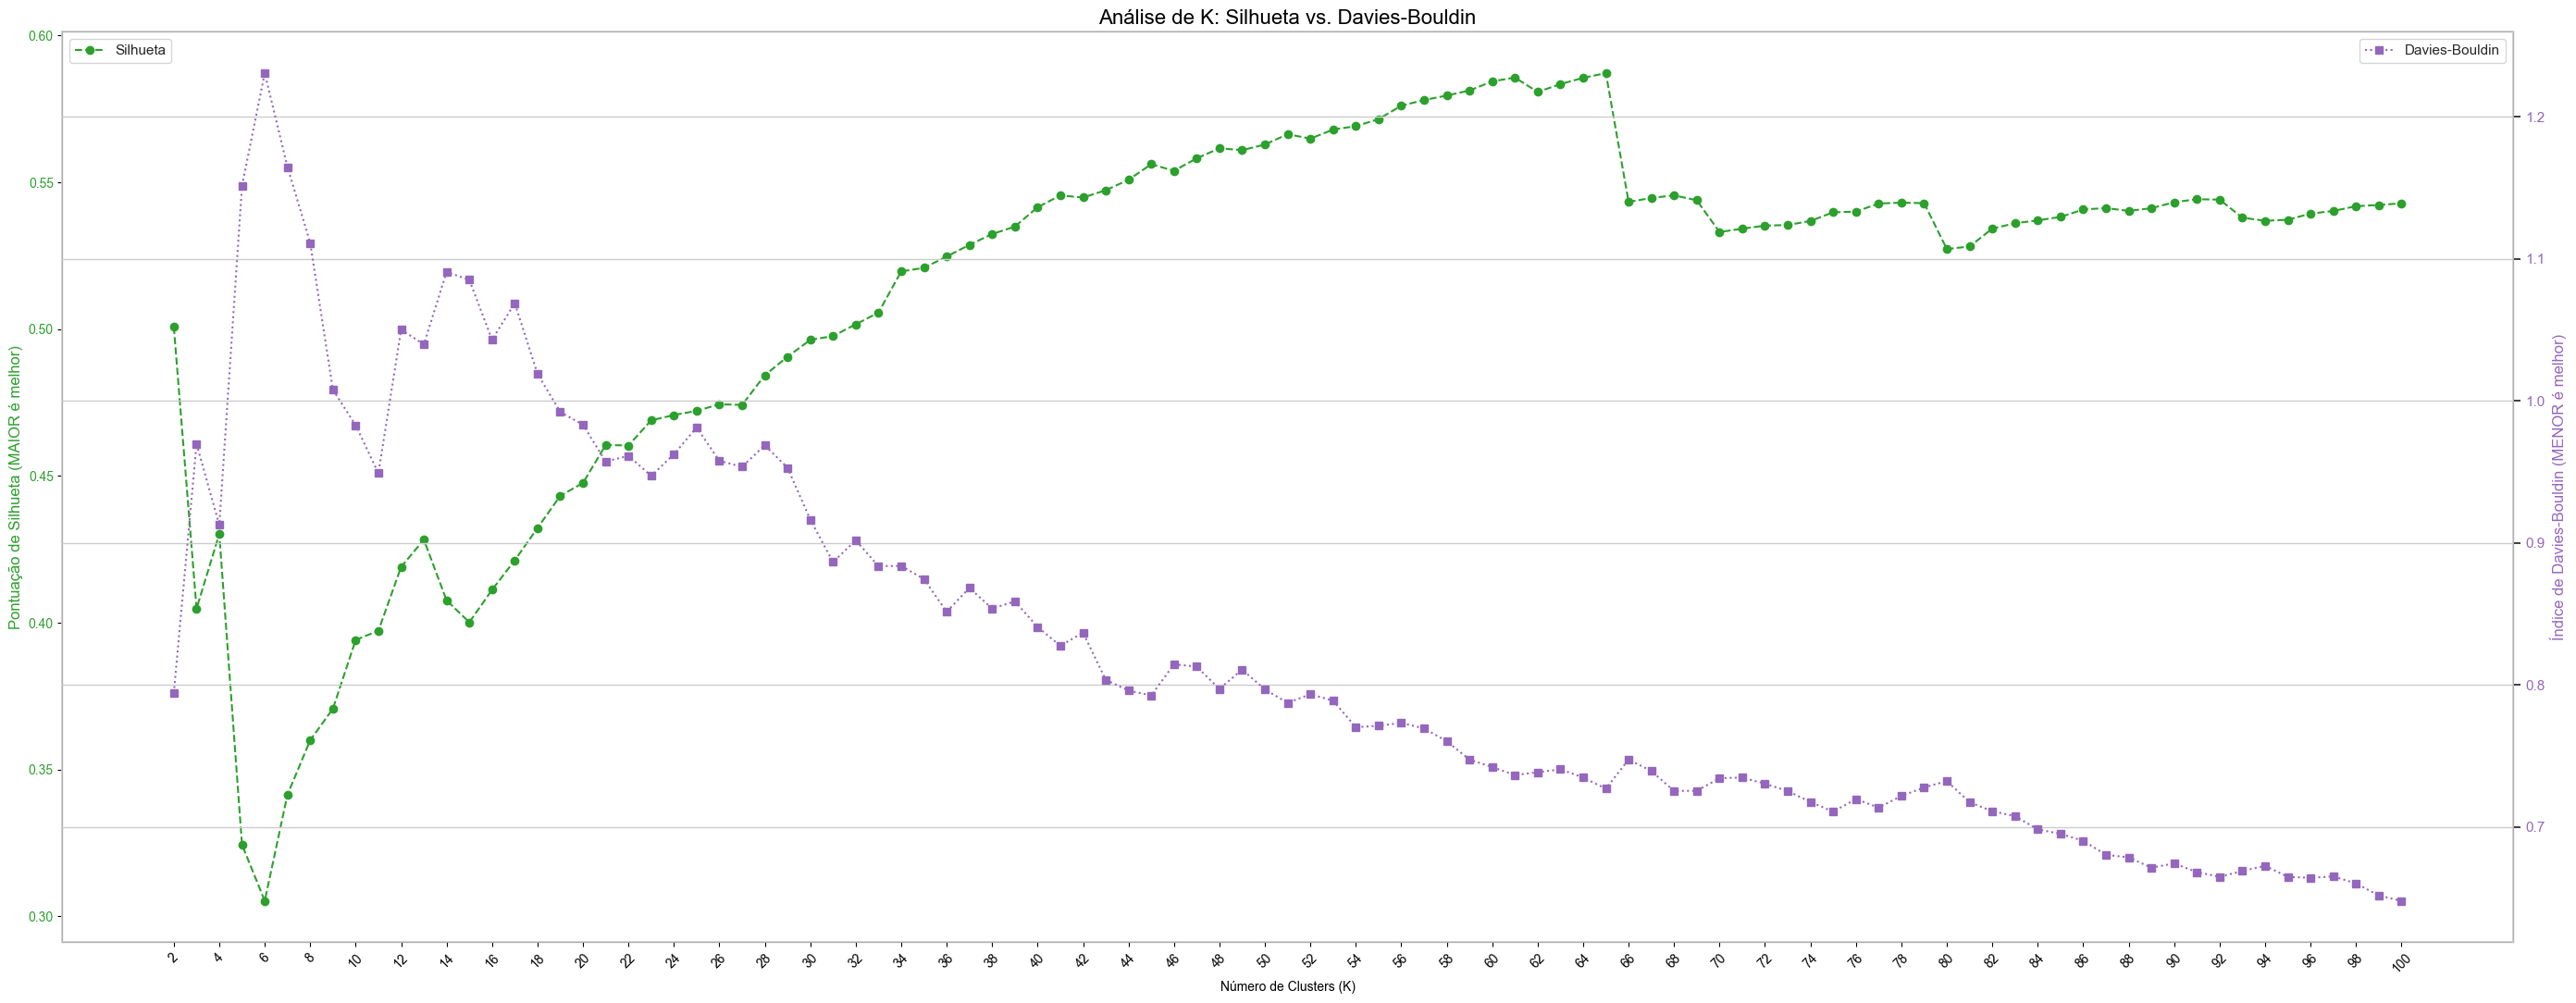

In [7]:
fig, ax1 = plt.subplots(figsize=(28, 11))
sns.set_theme(style="whitegrid")
plt.title('Análise de K: Silhueta vs. Davies-Bouldin', fontsize=16)

#Silhueta 
color = 'tab:green'
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Pontuação de Silhueta (MAIOR é melhor)', color=color, fontsize=12)    
ax1.plot(k_range, silhouette_scores, marker='o', linestyle='--', color=color, label='Silhueta')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(np.arange(min(k_range), max(k_range)+1, 2))
plt.xticks(rotation=45)
ax1.legend(loc='upper left') 

#Davies-Bouldin
ax2 = ax1.twinx()
color = 'tab:purple'
ax2.set_ylabel('Índice de Davies-Bouldin (MENOR é melhor)', color=color, fontsize=12)
ax2.plot(k_range, db_scores, marker='s', linestyle=':', color=color, label='Davies-Bouldin')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()
plt.grid(True)
plt.show()

#### Melhor K — Silhueta (Hierárquico)

In [8]:
max_silhouette_score = max(silhouette_scores)
best_k_index = silhouette_scores.index(max_silhouette_score)
best_k_silhueta = k_range[best_k_index]

print(f"Melhor K={best_k_silhueta} Pontuação de Silhueta de {max_silhouette_score:.4f}.")

Melhor K=65 Pontuação de Silhueta de 0.5872.


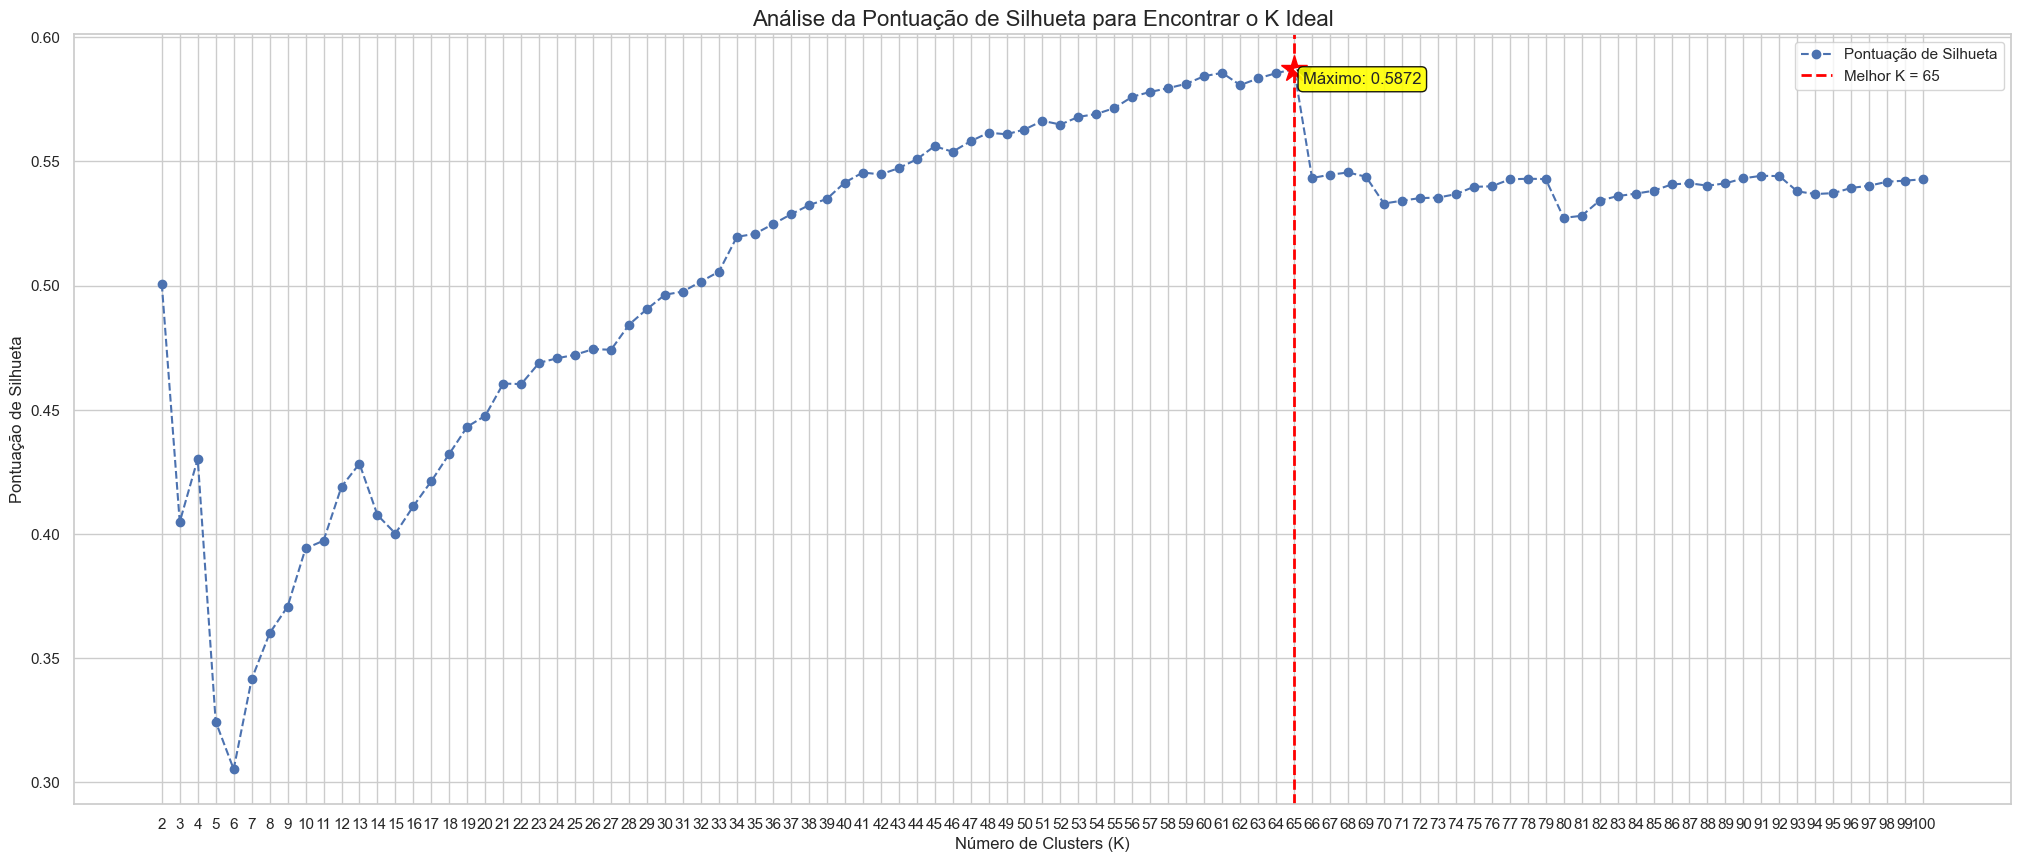

In [9]:
plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")
plt.title('Análise da Pontuação de Silhueta para Encontrar o K Ideal', fontsize=16)

plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='b', label='Pontuação de Silhueta')

plt.axvline(x=best_k_silhueta, color='red', linestyle='--', linewidth=2, label=f'Melhor K = {best_k_silhueta}')

plt.plot(best_k_silhueta, max_silhouette_score, marker='*', markersize=20, color='red')

plt.annotate(f'Máximo: {max_silhouette_score:.4f}',
             xy=(best_k_silhueta, max_silhouette_score),
             xytext=(best_k_silhueta + 0.5, max_silhouette_score * 0.99),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.9))

plt.xlabel('Número de Clusters (K)')
plt.ylabel('Pontuação de Silhueta')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

#### Melhor K — DB Score (Hierárquico)

In [10]:
min_db_score = min(db_scores)

best_k_index = db_scores.index(min_db_score)
best_k = k_range[best_k_index]
print(f"DB_score {min_db_score:.4f} e o K={best_k}.")

DB_score 0.6478 e o K=100.


Análise concluída: O melhor Índice de Davies-Bouldin foi 0.6478, alcançado com K=100.


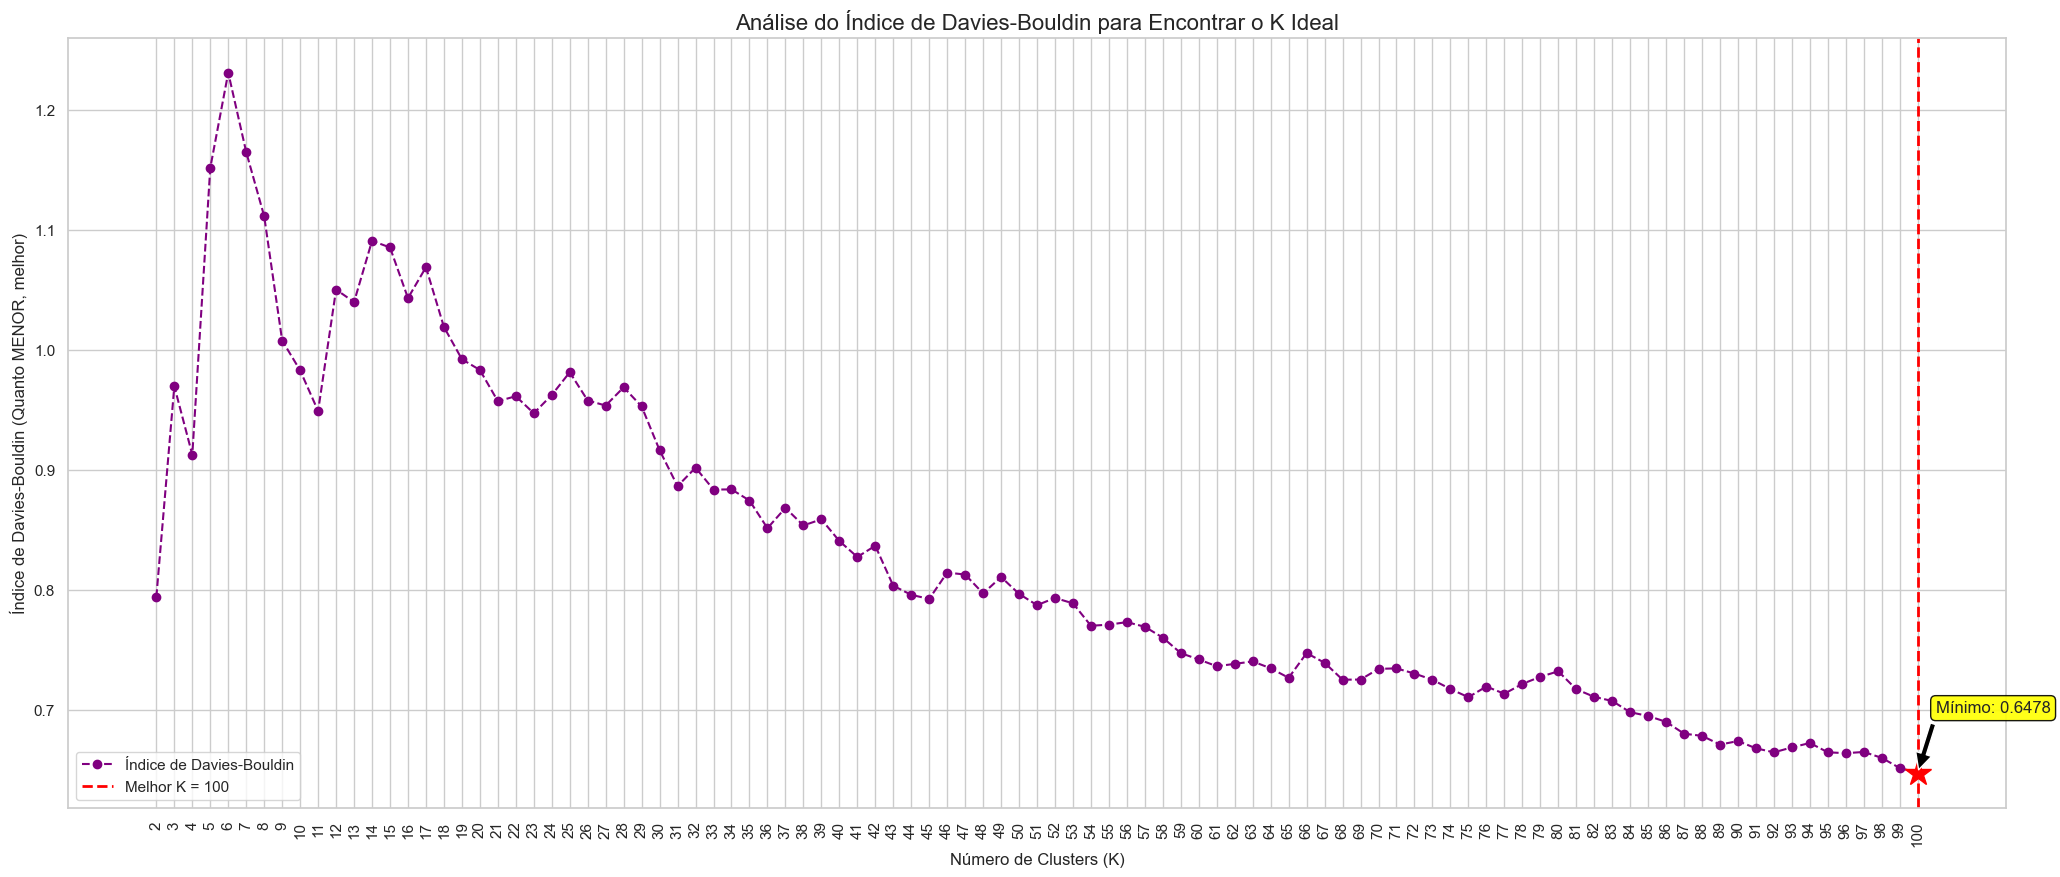

In [11]:
# Melhor K 
min_db_score = min(db_scores)
best_k_index = db_scores.index(min_db_score)
best_k = k_range[best_k_index]

print(f"Análise concluída: O melhor Índice de Davies-Bouldin foi {min_db_score:.4f}, alcançado com K={best_k}.")

# Gráfico
plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")
plt.title('Análise do Índice de Davies-Bouldin para Encontrar o K Ideal', fontsize=16)

plt.plot(k_range, db_scores, marker='o', linestyle='--', color='purple', label='Índice de Davies-Bouldin')

plt.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Melhor K = {best_k}')
plt.plot(best_k, min_db_score, marker='*', markersize=20, color='red')
plt.annotate(f'Mínimo: {min_db_score:.4f}',
             xy=(best_k, min_db_score),
             xytext=(best_k + 1, min_db_score + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.9))

plt.xlabel('Número de Clusters (K)')
plt.ylabel('Índice de Davies-Bouldin (Quanto MENOR, melhor)')
plt.xticks(k_range)
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

### Modelo K-MEANS vs. Métricas

In [12]:
silhouette_scores_kmeans = []
db_scores_kmeans = []
k_range_kmeans = range(2, 101) 

for k in k_range_kmeans:
    kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans_model.fit_predict(dados_para_modelo)
    
    silhouette_scores_kmeans.append(silhouette_score(dados_para_modelo, labels))
    db_scores_kmeans.append(davies_bouldin_score(dados_para_modelo, labels))

#### Melhor K — Silhueta (K-Means)

In [13]:
max_sil_score_kmeans = max(silhouette_scores_kmeans)
best_k_sil_index_kmeans = silhouette_scores_kmeans.index(max_sil_score_kmeans)
best_k_sil_kmeans = k_range_kmeans[best_k_sil_index_kmeans]

print(f"  O melhor K é: {best_k_sil_kmeans}")
print(f"  Com uma pontuação máxima de: {max_sil_score_kmeans:.4f}")

  O melhor K é: 56
  Com uma pontuação máxima de: 0.5800


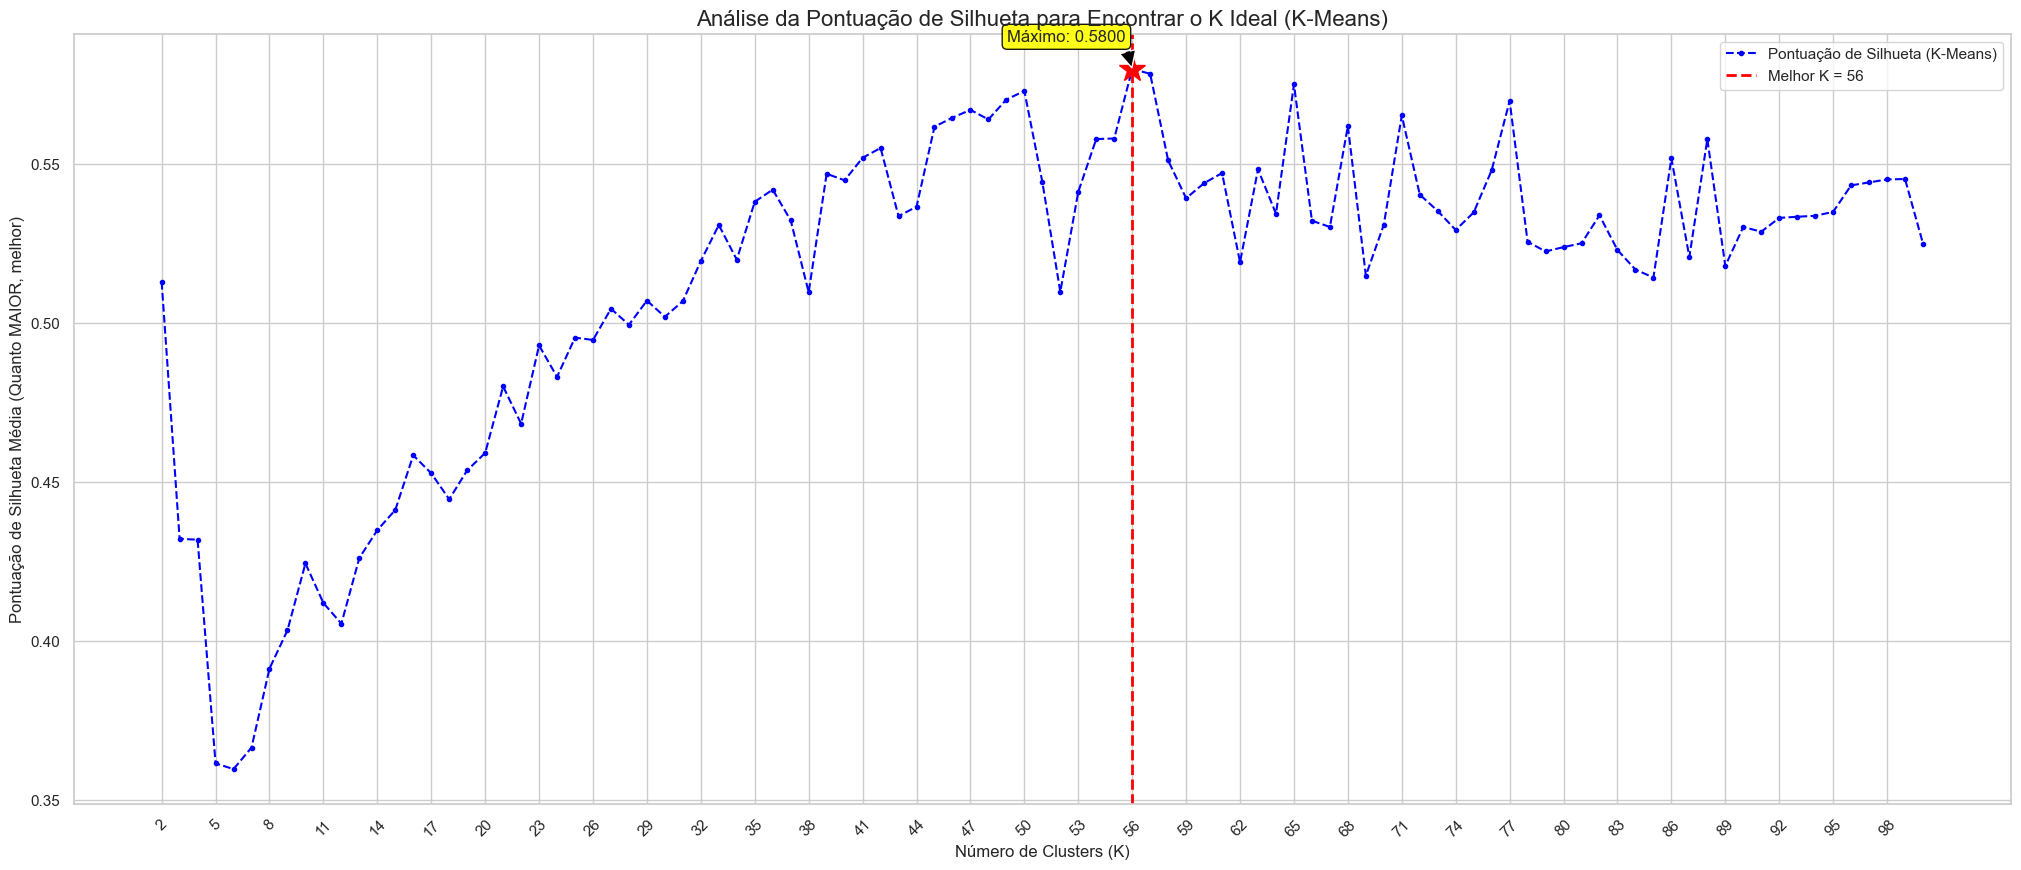

In [14]:
plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")
plt.title('Análise da Pontuação de Silhueta para Encontrar o K Ideal (K-Means)', fontsize=16)
plt.plot(k_range_kmeans, silhouette_scores_kmeans, marker='.', linestyle='--', color='blue', label='Pontuação de Silhueta (K-Means)')

plt.axvline(x=best_k_sil_kmeans, color='red', linestyle='--', linewidth=2, label=f'Melhor K = {best_k_sil_kmeans}')
plt.plot(best_k_sil_kmeans, max_sil_score_kmeans, marker='*', markersize=20, color='red')
plt.annotate(f'Máximo: {max_sil_score_kmeans:.4f}',
             xy=(best_k_sil_kmeans, max_sil_score_kmeans),
             xytext=(-90, 20) if best_k_sil_kmeans > 50 else (20, 20),
             textcoords='offset points',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.9))


plt.xlabel('Número de Clusters (K)')

plt.ylabel('Pontuação de Silhueta Média (Quanto MAIOR, melhor)')


ticks_personalizados = list(np.arange(min(k_range_kmeans), max(k_range_kmeans)+1, 3))
if best_k_sil_kmeans not in ticks_personalizados:
    ticks_personalizados.append(best_k_sil_kmeans)
ticks_personalizados.sort()
plt.xticks(ticks_personalizados, rotation=45)

plt.legend()
plt.grid(True)
plt.show()

#### Melhor K — DB Score (K-Means)

In [15]:
min_db_score_kmeans = min(db_scores_kmeans)
best_k_db_index_kmeans = db_scores_kmeans.index(min_db_score_kmeans)
best_k_db_kmeans = k_range_kmeans[best_k_db_index_kmeans]

print("      Análise do Índice de Davies-Bouldin (K-Means)")

print(f"  O melhor K é: {best_k_db_kmeans}")
print(f"  Com uma pontuação mínima de: {min_db_score_kmeans:.4f}")

      Análise do Índice de Davies-Bouldin (K-Means)
  O melhor K é: 88
  Com uma pontuação mínima de: 0.6062


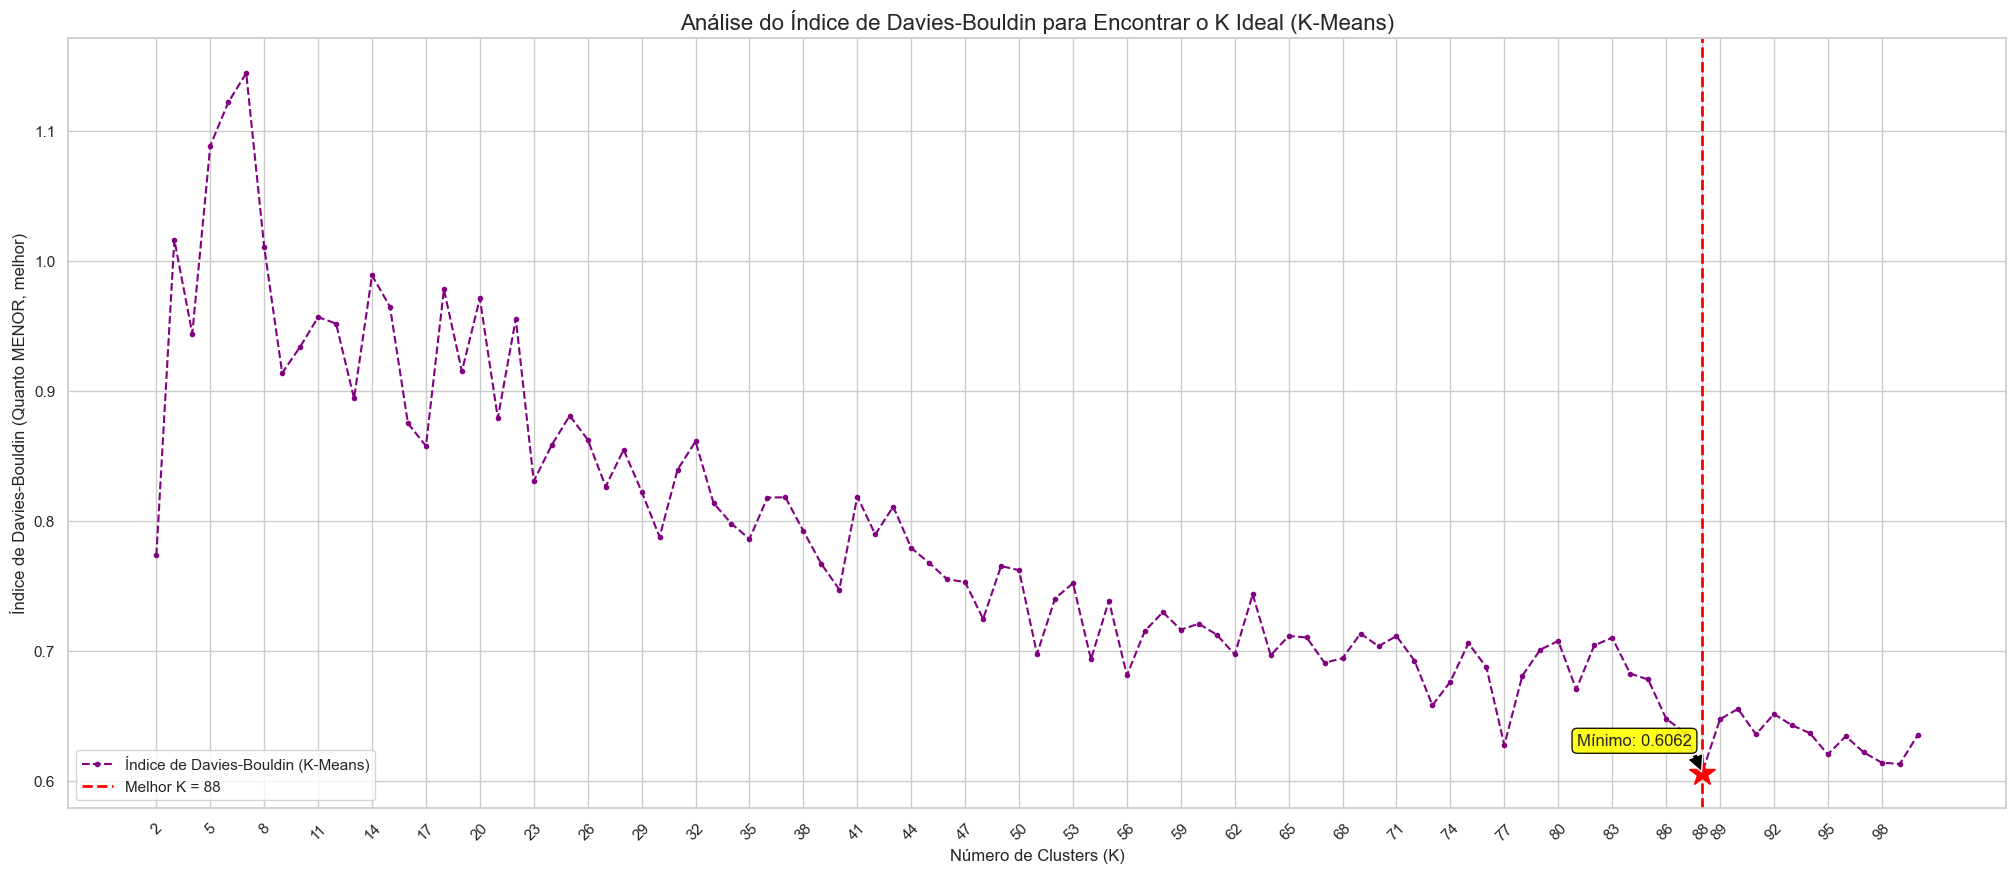

In [16]:
plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")
plt.title('Análise do Índice de Davies-Bouldin para Encontrar o K Ideal (K-Means)', fontsize=16)

plt.plot(k_range_kmeans, db_scores_kmeans, marker='.', linestyle='--', color='purple', label='Índice de Davies-Bouldin (K-Means)')
plt.axvline(x=best_k_db_kmeans, color='red', linestyle='--', linewidth=2, label=f'Melhor K = {best_k_db_kmeans}')
plt.plot(best_k_db_kmeans, min_db_score_kmeans, marker='*', markersize=20, color='red')
plt.annotate(f'Mínimo: {min_db_score_kmeans:.4f}',
             xy=(best_k_db_kmeans, min_db_score_kmeans),
             xytext=(-90, 20) if best_k_db_kmeans > 50 else (20, 20),
             textcoords='offset points',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.9))
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Índice de Davies-Bouldin (Quanto MENOR, melhor)')
ticks_personalizados = list(np.arange(min(k_range_kmeans), max(k_range_kmeans)+1, 3))
if best_k_db_kmeans not in ticks_personalizados:
    ticks_personalizados.append(best_k_db_kmeans)
ticks_personalizados.sort()
plt.xticks(ticks_personalizados, rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Tabela Consolidada

In [17]:
dados_para_tabela1 = [
    {
        'Modelo': 'K-Means',
        'Métrica': 'Pontuação de Silhueta',
        'Melhor K': best_k_sil_kmeans,
        'Melhor Pontuação': f"{max_sil_score_kmeans:.4f} (Maior é melhor)"
    },
    {
        'Modelo': 'K-Means',
        'Métrica': 'Índice de Davies-Bouldin',
        'Melhor K': best_k_db_kmeans,
        'Melhor Pontuação': f"{min_db_score_kmeans:.4f} (Menor é melhor)"
    },
    {
        'Modelo': 'Hierárquico (ward)',
        'Métrica': 'Pontuação de Silhueta',
        'Melhor K': best_k_silhueta, 
        'Melhor Pontuação': f"{max_silhouette_score:.4f} (Maior é melhor)"
    },
    {
        'Modelo': 'Hierárquico (ward)',
        'Métrica': 'Índice de Davies-Bouldin',
        'Melhor K': best_k,  
        'Melhor Pontuação': f"{min_db_score:.4f} (Menor é melhor)"
    }
]

df_resumo_metricas = pd.DataFrame(dados_para_tabela1)

print("--- Tabela Comparativa de Métricas e Melhor 'K' ---")
display(df_resumo_metricas)

--- Tabela Comparativa de Métricas e Melhor 'K' ---


,Modelo,Métrica,Melhor K,Melhor Pontuação
0,K-Means,Pontuação de Silhueta,56,0.5800 (Maior é melhor)
1,K-Means,Índice de Davies-Bouldin,88,0.6062 (Menor é melhor)
2,Hierárquico (ward),Pontuação de Silhueta,65,0.5872 (Maior é melhor)
3,Hierárquico (ward),Índice de Davies-Bouldin,100,0.6478 (Menor é melhor)


## Método de Mojena — Cluster Hierárquico

In [18]:
dados_para_modelo = df_model

linked = sch.linkage(dados_para_modelo, method='ward')

#Ponto de Corte (Regra de Mojena)
alturas_das_fusoes = linked[:, 2]

#média e o desvio padrão dessas alturas
media_alturas = np.mean(alturas_das_fusoes)
std_alturas = np.std(alturas_das_fusoes)

#k
k_mojena = 1.25

#Regra de Mojena
ponto_de_corte_mojena = media_alturas + k_mojena * std_alturas
print(f"Ponto de corte calculado pela Regra de Mojena: {ponto_de_corte_mojena:.2f}")


# fcluster com o novo ponto de corte ---
labels_automaticos = fcluster(linked, t=ponto_de_corte_mojena, criterion='distance')

k_encontrado = len(np.unique(labels_automaticos))
print(f"\nCom base na Regra de Mojena, o modelo sugeriu {k_encontrado} clusters.")

Ponto de corte calculado pela Regra de Mojena: 4.09

Com base na Regra de Mojena, o modelo sugeriu 47 clusters.


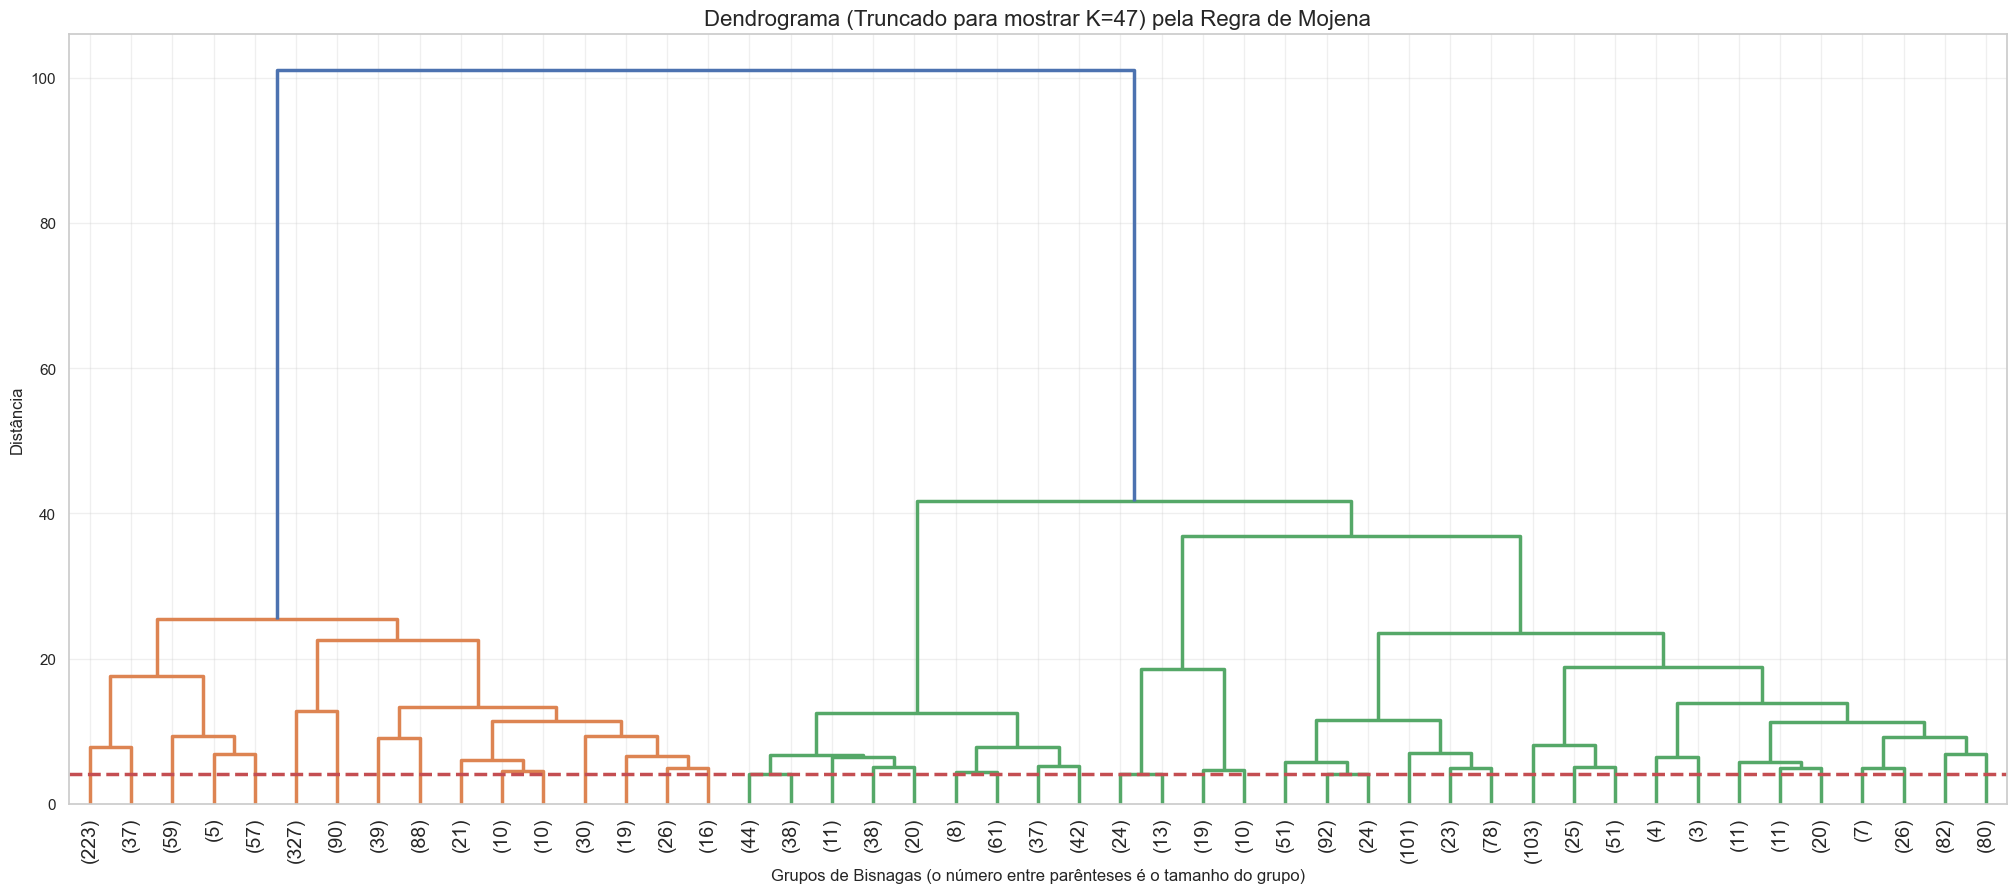

In [19]:
fig, ax = plt.subplots(figsize=(25, 10))
sns.set_theme(style="whitegrid")

dendrogram = sch.dendrogram(
    linked,
    truncate_mode='lastp',
    p=k_encontrado,
    show_leaf_counts=True,
    ax=ax
)
for collection in ax.collections:
    collection.set_linewidth(2.5)

plt.axhline(y=ponto_de_corte_mojena, color='r', linestyle='--', linewidth=2.5)


plt.title(f'Dendrograma (Truncado para mostrar K={k_encontrado}) pela Regra de Mojena', fontsize=16)
plt.ylabel('Distância')
plt.xlabel('Grupos de Bisnagas (o número entre parênteses é o tamanho do grupo)')

ax.grid(alpha=0.3)

ax.tick_params(axis='x', labelsize=14)



plt.show()

## Gráfico de Cotovelo — K-Means

In [20]:
dados_para_modelo = df_model

inertia_values = []
k_range = range(2, 101)

for k in k_range:
   
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(dados_para_modelo)
    inertia_values.append(kmeans.inertia_)

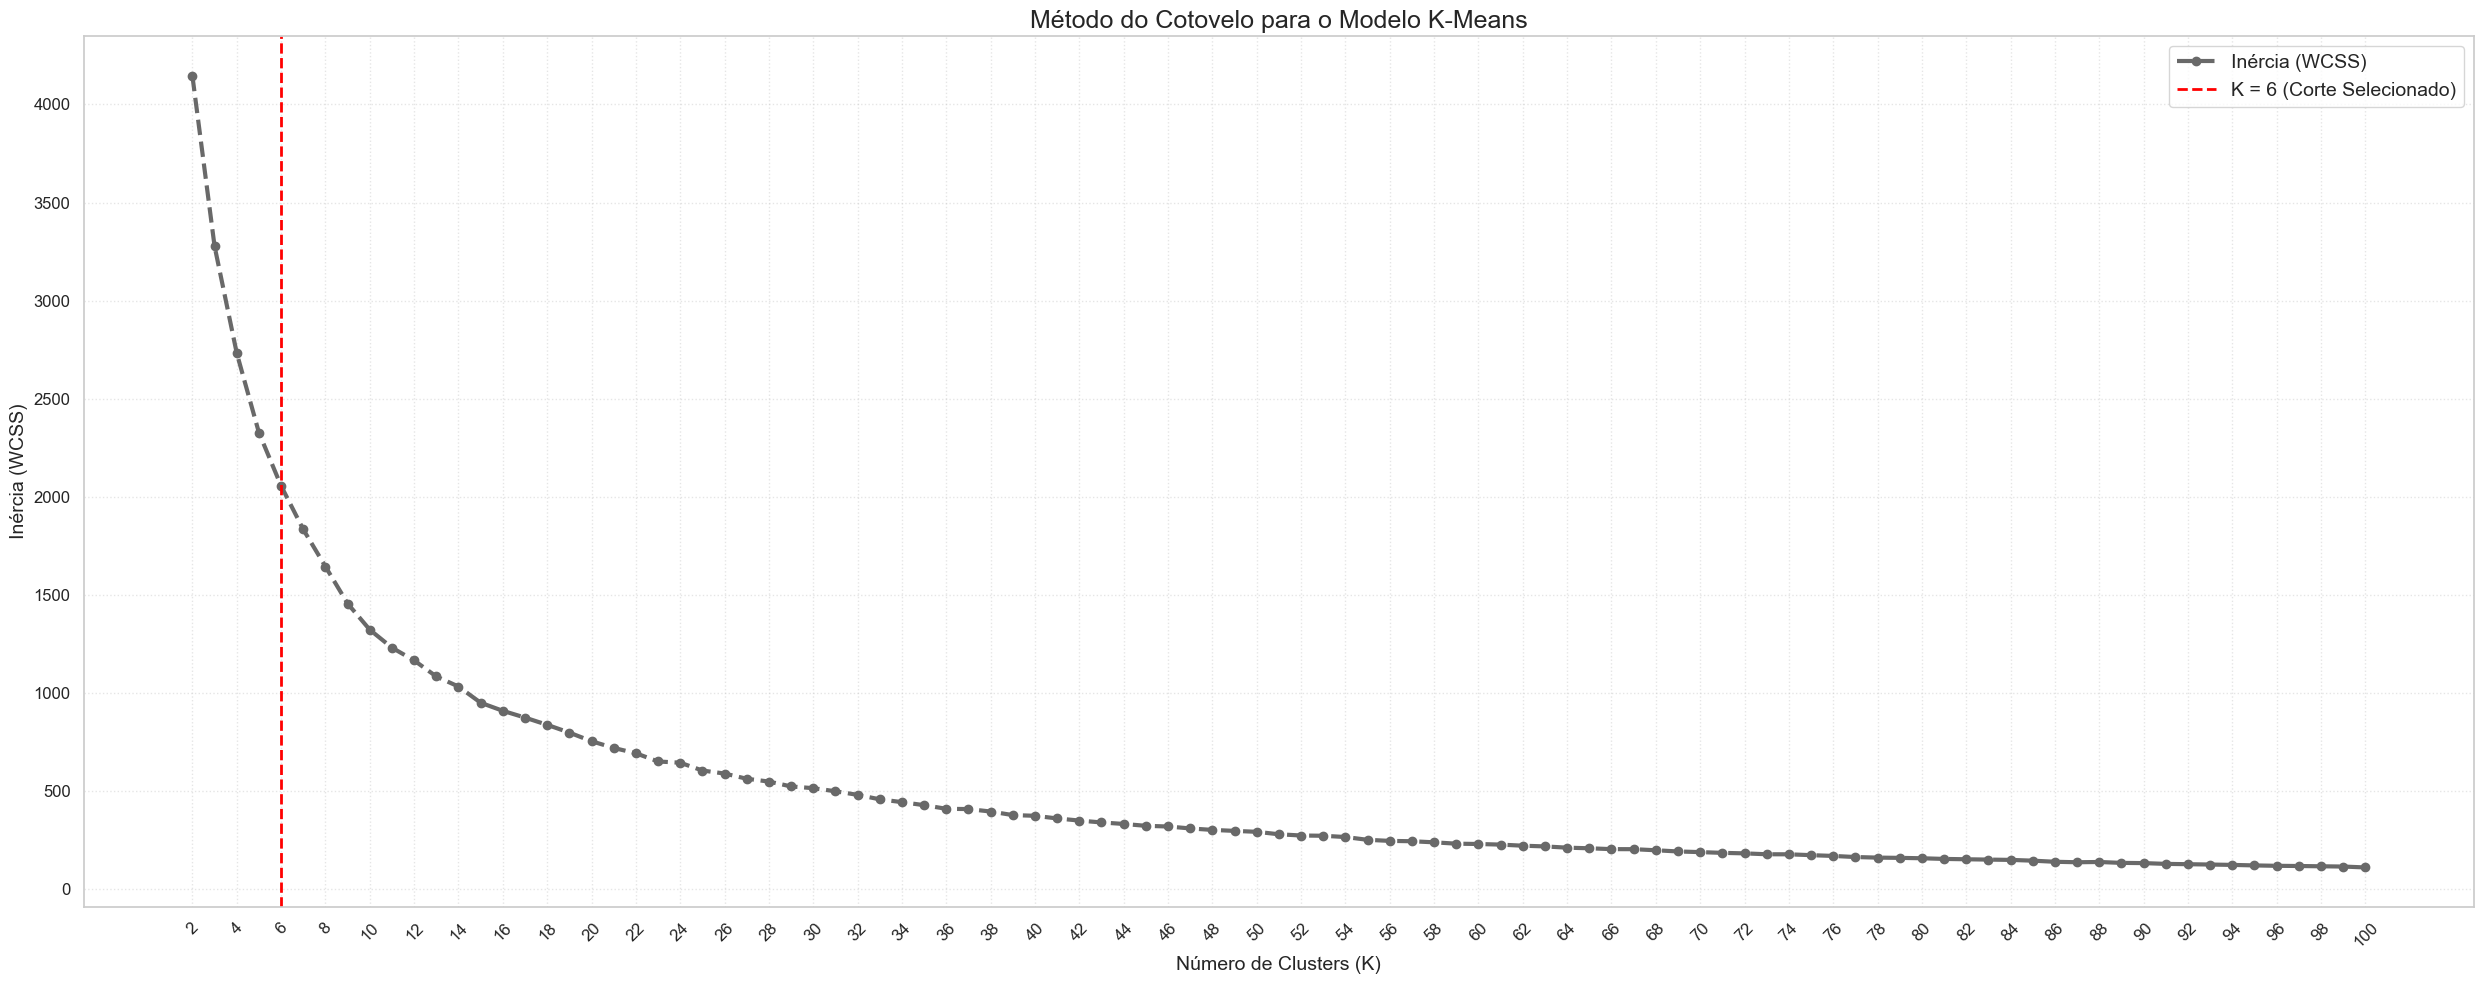

In [21]:
k_corte_elbow = 6


plt.figure(figsize=(25, 10))
sns.set_theme(style="whitegrid")

plt.plot(
    k_range, 
    inertia_values, 
    marker='o', 
    linestyle='--', 
    color='dimgray',  
    linewidth=3.0,   
    label='Inércia (WCSS)'
)

#Linha de Corte
plt.axvline(
    x=k_corte_elbow, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'K = {k_corte_elbow} (Corte Selecionado)'
)

#Rótulos
plt.title('Método do Cotovelo para o Modelo K-Means', fontsize=18)
plt.xlabel('Número de Clusters (K)', fontsize=14)
plt.ylabel('Inércia (WCSS)', fontsize=14)

ticks_personalizados = list(np.arange(min(k_range), max(k_range)+1, 2))
if k_corte_elbow not in ticks_personalizados:
    ticks_personalizados.append(k_corte_elbow)
ticks_personalizados.sort()

plt.xticks(ticks_personalizados, rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5) 

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### Comparativo: Mojena + Cotovelo

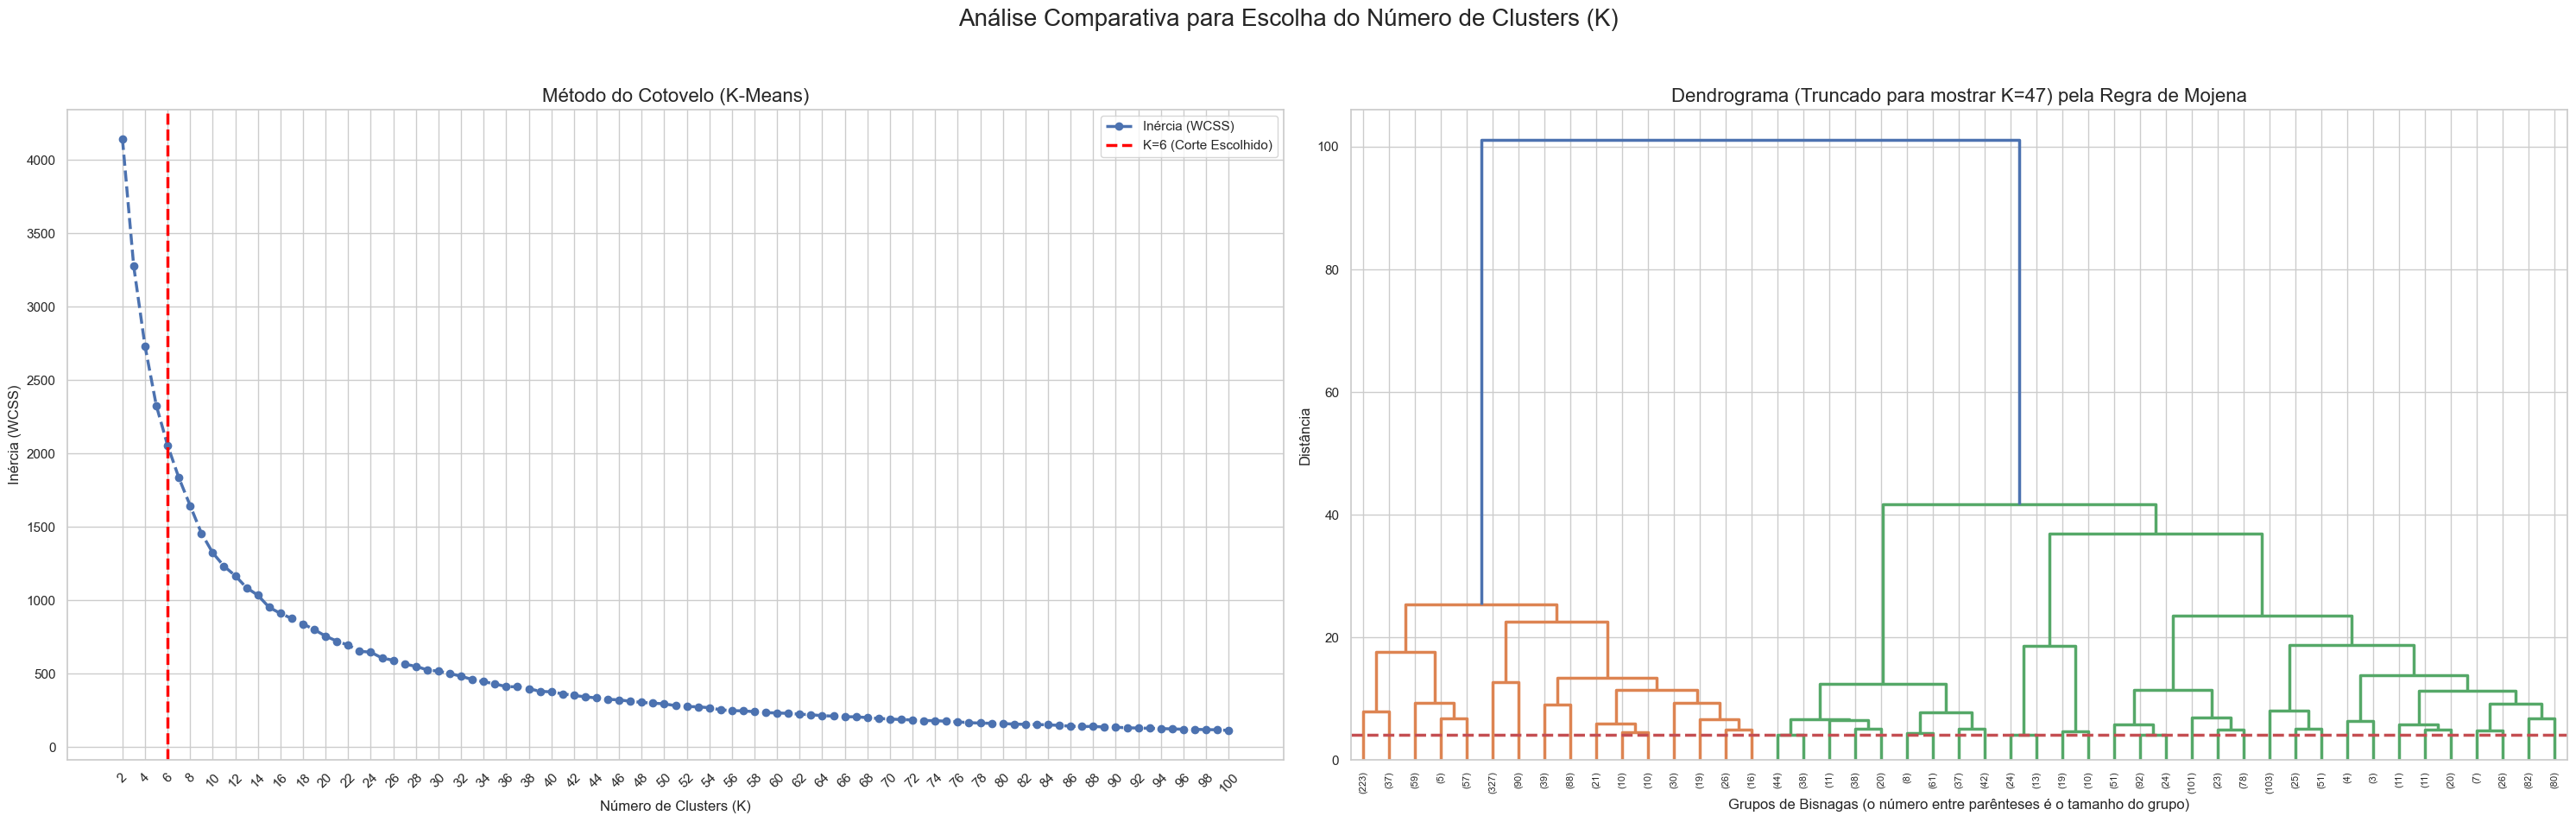

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))
sns.set_theme(style="whitegrid")
fig.suptitle('Análise Comparativa para Escolha do Número de Clusters (K)', fontsize=20)


#Gráfico 1: Método elbow(K-Means) ---
ax1.plot(k_range, inertia_values, marker='o', linestyle='--', linewidth=2.5, label='Inércia (WCSS)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia (WCSS)')
ax1.set_title('Método do Cotovelo (K-Means)', fontsize=16)
# Ajustando os ticks do eixo X
ax1.set_xticks(np.arange(min(k_range), max(k_range)+1, 2))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

ax1.axvline(x=6, color='red', linestyle='--', linewidth=2.5, label='K=6 (Corte Escolhido)')
ax1.legend() 


#Gráfico 2: Dendrograma (Hierárquico / Mojena) ---
dendrogram = sch.dendrogram(
    linked,
    truncate_mode='lastp',
    p=k_encontrado,
    show_leaf_counts=True,
    ax=ax2
)

for collection in ax2.collections:
    collection.set_linewidth(2.5)

# Linha de corte
ax2.axhline(y=ponto_de_corte_mojena, color='r', linestyle='--', linewidth=2.5)

ax2.set_title(f'Dendrograma (Truncado para mostrar K={k_encontrado}) pela Regra de Mojena', fontsize=16)
ax2.set_ylabel('Distância')
ax2.set_xlabel('Grupos de Bisnagas (o número entre parênteses é o tamanho do grupo)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para o título principal caber
plt.show()

### Comparativo: Silhueta K-Means vs. Hierárquico

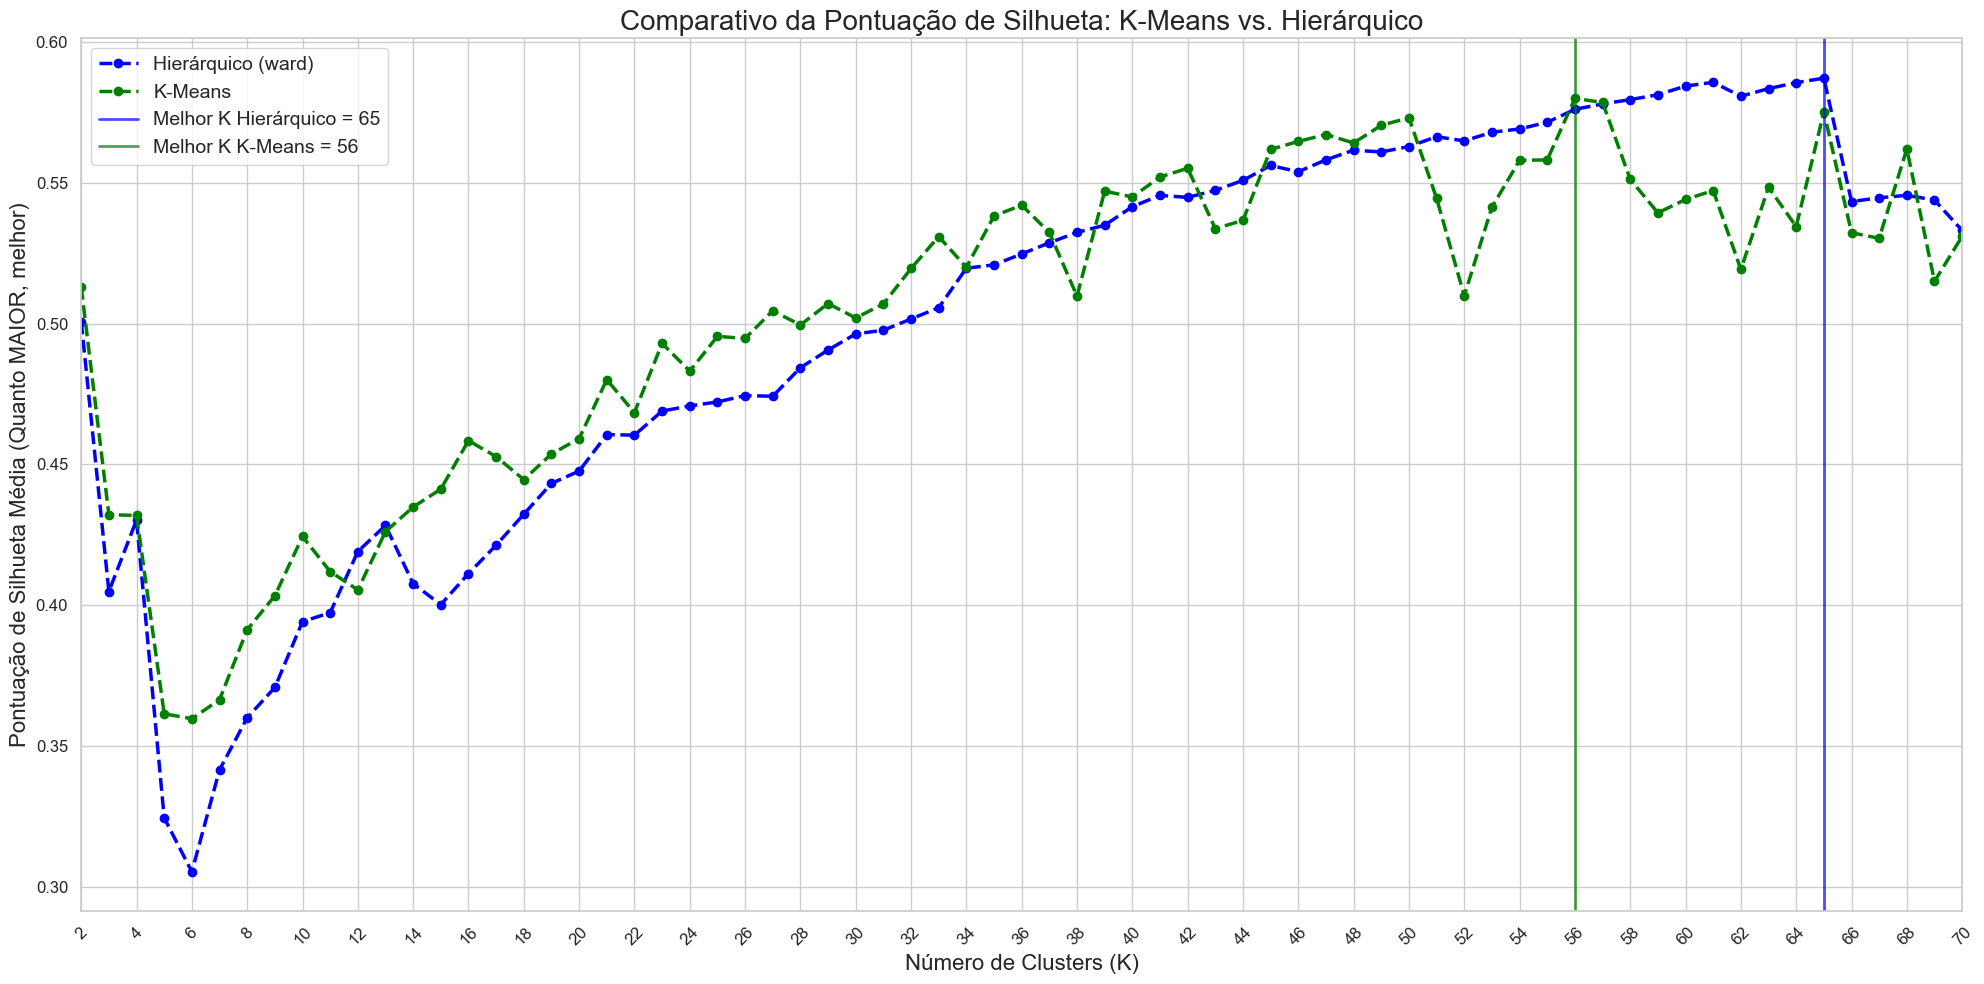

In [23]:
plt.figure(figsize=(20, 10)) 
sns.set_theme(style="whitegrid")

fs_titulo = 20
fs_labels = 16
fs_legend = 14
fs_ticks = 12

#Modelo Hierárquico (Azul)
plt.plot(
    k_range, 
    silhouette_scores, 
    marker='o', 
    linestyle='--', 
    color='blue', 
    label='Hierárquico (ward)', 
    linewidth=2.5
)

#K-Means (Verde)
plt.plot(
    k_range_kmeans, 
    silhouette_scores_kmeans, 
    marker='o', 
    linestyle='--', 
    color='green', 
    label='K-Means', 
    linewidth=2.5
)

plt.axvline(x=best_k_silhueta, color='blue', linestyle='-', linewidth=2, alpha=0.7, label=f'Melhor K Hierárquico = {best_k_silhueta}')
plt.axvline(x=best_k_sil_kmeans, color='green', linestyle='-', linewidth=2, alpha=0.7, label=f'Melhor K K-Means = {best_k_sil_kmeans}')

plt.title('Comparativo da Pontuação de Silhueta: K-Means vs. Hierárquico', fontsize=fs_titulo)
plt.xlabel('Número de Clusters (K)', fontsize=fs_labels)
plt.ylabel('Pontuação de Silhueta Média (Quanto MAIOR, melhor)', fontsize=fs_labels)

ticks_novos = np.arange(min(k_range), 71, 2) 

plt.xticks(ticks_novos, rotation=45, fontsize=fs_ticks)

plt.xlim(min(k_range), 70)


plt.yticks(fontsize=fs_ticks)
plt.legend(fontsize=fs_legend)
plt.grid(True)
plt.tight_layout()
plt.show()